# Question 3: Housing Price Prediction using Steepest Descent

## 1. Problem Statement
We model the relationship between house features and price using a linear model:
$$Ax \approx b$$
where:
* $A \in \mathbb{R}^{m \times n}$ is the feature matrix (housing attributes).
* $x \in \mathbb{R}^{n}$ is the vector of regression coefficients.
* $b \in \mathbb{R}^{m}$ is the vector of observed house prices.

We estimate $x$ by solving the least squares problem:
$$\min_{x \in \mathbb{R}^{n}} J(x) = \frac{1}{2} \|Ax - b\|^2$$

---

## 2. Mathematical Derivation (Part a)

### 2.1 Gradient of the Cost Function
The cost function is $J(x) = \frac{1}{2}(Ax - b)^T(Ax - b)$. [cite_start]Expanding this or using the chain rule[cite: 33]:
$$\nabla J(x) = A^T(Ax - b)$$ 
Let the residual be $r_k = Ax^{(k)} - b$. Then the gradient is:
$$\nabla J(x^{(k)}) = A^T r_k$$ 

### 2.2 Optimal Step Size ($\alpha_k$)
To find the optimal step size that minimizes $J(x^{(k)} - \alpha \nabla J(x^{(k)}))$, we use the formula provided in the assignment:
$$\alpha_k = \frac{r_k^T r_k}{r_k^T A A^T r_k}$$

### 2.3 Steepest Descent Update Rule
The parameters are updated iteratively using the gradient and the optimal step size:
$$x^{(k+1)} = x^{(k)} - \alpha_k A^T r_k$$ 

## 3. Code Implementation & Plotting (Part b)


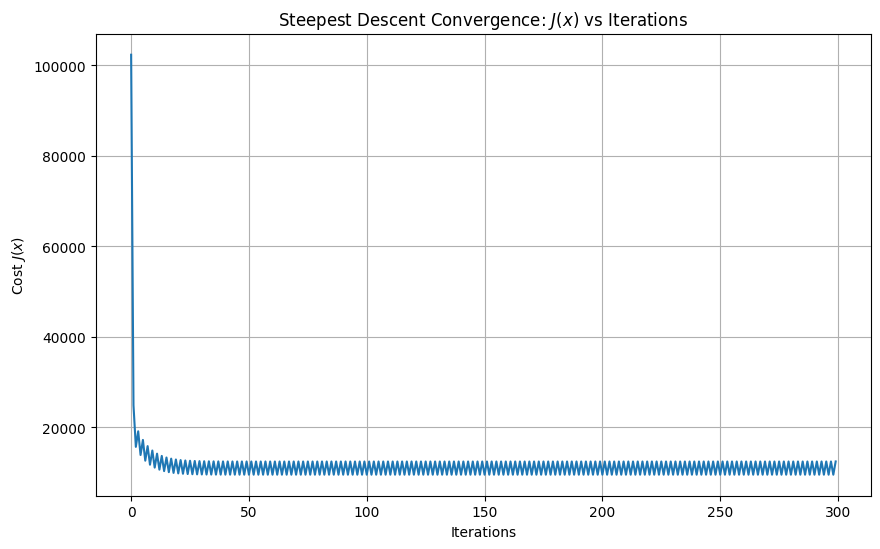

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing

# i. Load the dataset
A, b = fetch_california_housing(return_X_y=True)

# ii. Normalize features (mean 0, variance 1)
A = (A - np.mean(A, axis=0)) / np.std(A, axis=0)

# iii. Add bias term (column of ones)
A = np.c_[np.ones(A.shape[0]), A]

# iv. Initialize x(0) randomly
np.random.seed(42)
x = np.random.randn(A.shape[1])

# v. Implement Steepest Descent
iterations = 300
cost_history = []

for k in range(iterations):
    # Compute residual: r_k = Ax(k) - b
    r = A @ x - b
    
    # Store current cost
    cost = 0.5 * np.sum(r**2)
    cost_history.append(cost)
    
    # Compute gradient: A^T * r_k
    grad = A.T @ r
    
    # Compute optimal step size alpha_k
    num = r.T @ r
    den = r.T @ A @ A.T @ r
    alpha = num / den
    
    # Update: x(k+1) = x(k) - alpha_k * gradient
    x = x - alpha * grad

# vii. Plot the cost function versus iterations
plt.figure(figsize=(10, 6))
plt.plot(range(iterations), cost_history)
plt.title(r'Steepest Descent Convergence: $J(x)$ vs Iterations')
plt.xlabel('Iterations')
plt.ylabel(r'Cost $J(x)$')
plt.grid(True)
plt.show()

#### Submited by: Bammidi Pragati Rao
#### Roll No. : 252CD005